<a href="https://colab.research.google.com/github/DataEtnos/ANALISES-DE-CUSTO-DE-SEGURO-DE-VIDA/blob/main/ANALISES_DE_CUSTO_DE_SEGURO_DE_VIDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [143]:
#Setup
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt




#machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler, MinMaxScaler, LabelEncoder, StandardScaler
from sklearn import metrics
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

from sklearn import metrics as metrics

# Pré-processamento para incluir no pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder,MinMaxScaler
from sklearn.compose import ColumnTransformer


In [122]:
#data frame
df = pd.read_csv("/content/insurance.csv")
df.head()

,idade,sexo,imc,quantidade_filhos,fumante,regiao,custos_seguro
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.560,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [123]:
#verificando informações do dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1341 entries, 0 to 1340
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   idade              1341 non-null   int64  
 1   sexo               1338 non-null   object 
 2   imc                1341 non-null   float64
 3   quantidade_filhos  1341 non-null   int64  
 4   fumante            1341 non-null   object 
 5   regiao             1341 non-null   object 
 6   custos_seguro      1341 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.5+ KB


In [124]:
#observando as estatistica descritivas dos dados
df.describe()

,idade,imc,quantidade_filhos,custos_seguro
count,1341.000000,1341.000000,1341.000000,1341.000000
mean,39.186428,30.684903,1.092468,13240.734520
std,14.040969,6.107806,1.205254,12112.696927
min,18.000000,15.960000,0.000000,0.000000
25%,27.000000,26.315000,0.000000,4719.524050
50%,39.000000,30.400000,1.000000,9361.326800
75%,51.000000,34.770000,2.000000,16586.497710
max,64.000000,53.130000,5.000000,63770.428010


In [125]:
#contagem de nulo
print(df.isnull().sum())

#exclusão de nulos
df.dropna(inplace=True)

idade                0
sexo                 3
imc                  0
quantidade_filhos    0
fumante              0
regiao               0
custos_seguro        0
dtype: int64


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1338 entries, 0 to 1340
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   idade              1338 non-null   int64  
 1   sexo               1338 non-null   object 
 2   imc                1338 non-null   float64
 3   quantidade_filhos  1338 non-null   int64  
 4   fumante            1338 non-null   object 
 5   regiao             1338 non-null   object 
 6   custos_seguro      1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [127]:
# pegando os valores de contagem de cada variavel das colunas . ex =  quantos pessoas de idade de 18 temos = 69 pessoas cadastrada neste dataframe
for column in df.columns:
  print(df[column].value_counts())
  print('\n')

idade
18    69
19    68
50    29
51    29
47    29
46    29
45    29
20    29
48    29
52    29
22    28
49    28
54    28
53    28
21    28
26    28
24    28
25    28
28    28
27    28
23    28
43    27
29    27
30    27
41    27
42    27
44    27
31    27
40    27
32    26
33    26
56    26
34    26
55    26
57    26
37    25
59    25
58    25
36    25
38    25
35    25
39    25
61    23
60    23
63    23
62    23
64    22
Name: count, dtype: int64


sexo
male      676
female    662
Name: count, dtype: int64


imc
32.300    13
28.310     9
30.875     8
31.350     8
28.880     8
          ..
46.700     1
46.200     1
23.800     1
44.770     1
30.970     1
Name: count, Length: 549, dtype: int64


quantidade_filhos
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64


fumante
no     1064
yes     274
Name: count, dtype: int64


regiao
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


custos_seguro
1639.56310     2


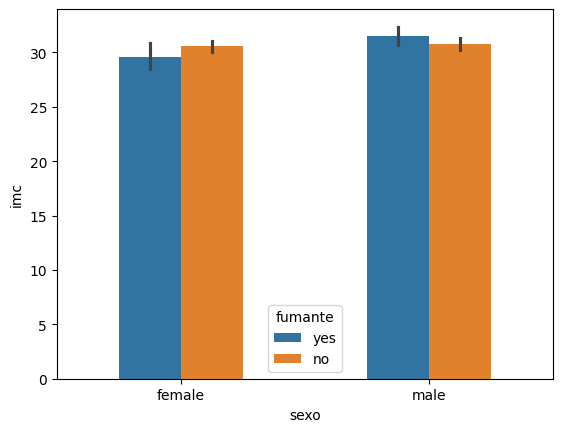

In [128]:
#comparação de fumantes imc  por sexo
bar_plot = sns.barplot(data=df, x='sexo', y='imc', hue='fumante',width = 0.5)

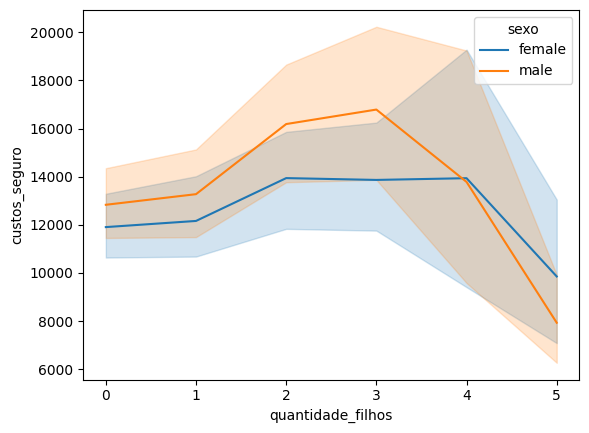

In [129]:
#vericando em grafico quantidade de filhos e valores de seguro por diferenciação de
lineplot = sns.lineplot(data=df, x='quantidade_filhos', y='custos_seguro', hue='sexo')

(array([287., 249., 205., 193.,  71.,  58.,  46.,  40.,  25.,  10.,  25.,
         34.,  30.,  27.,  22.,  10.,   1.,   1.,   2.,   2.]),
 array([ 1121.8739   ,  4254.3016055,  7386.729311 , 10519.1570165,
        13651.584722 , 16784.0124275, 19916.440133 , 23048.8678385,
        26181.295544 , 29313.7232495, 32446.150955 , 35578.5786605,
        38711.006366 , 41843.4340715, 44975.861777 , 48108.2894825,
        51240.717188 , 54373.1448935, 57505.572599 , 60638.0003045,
        63770.42801  ]),
 <BarContainer object of 20 artists>)

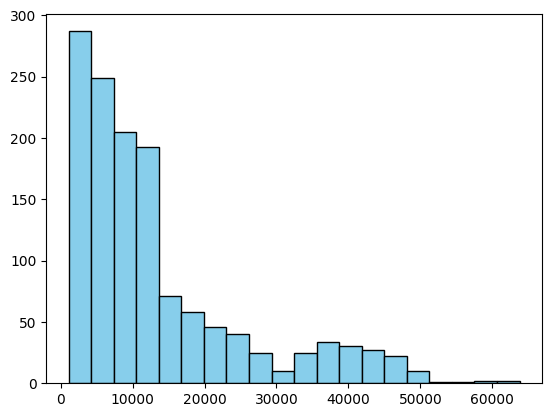

In [130]:
#verificando a distribuição de valores de custo do seuros
plt.hist(df['custos_seguro'], bins=20, color='skyblue', edgecolor='black')

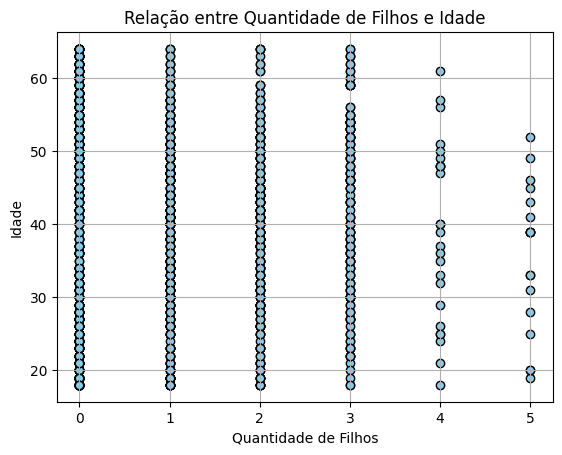

In [152]:

#observando a quantidade de filhos  por idade do cadastrado na base
plt.scatter(df['quantidade_filhos'], df['idade'], color='skyblue', edgecolor='black')


plt.title('Relação entre Quantidade de Filhos e Idade')
plt.xlabel('Quantidade de Filhos')
plt.ylabel('Idade')
plt.grid(True)


plt.show()

In [153]:
#separado colunas categoria e numericas  e definindo preditores e alvo
Colunas_categoricas = ['sexo', 'fumante', 'regiao']
colunas_numericas = ['idade', 'quantidade_filhos', 'imc']
features =  Colunas_categoricas + colunas_numericas
target = 'custos_seguro'

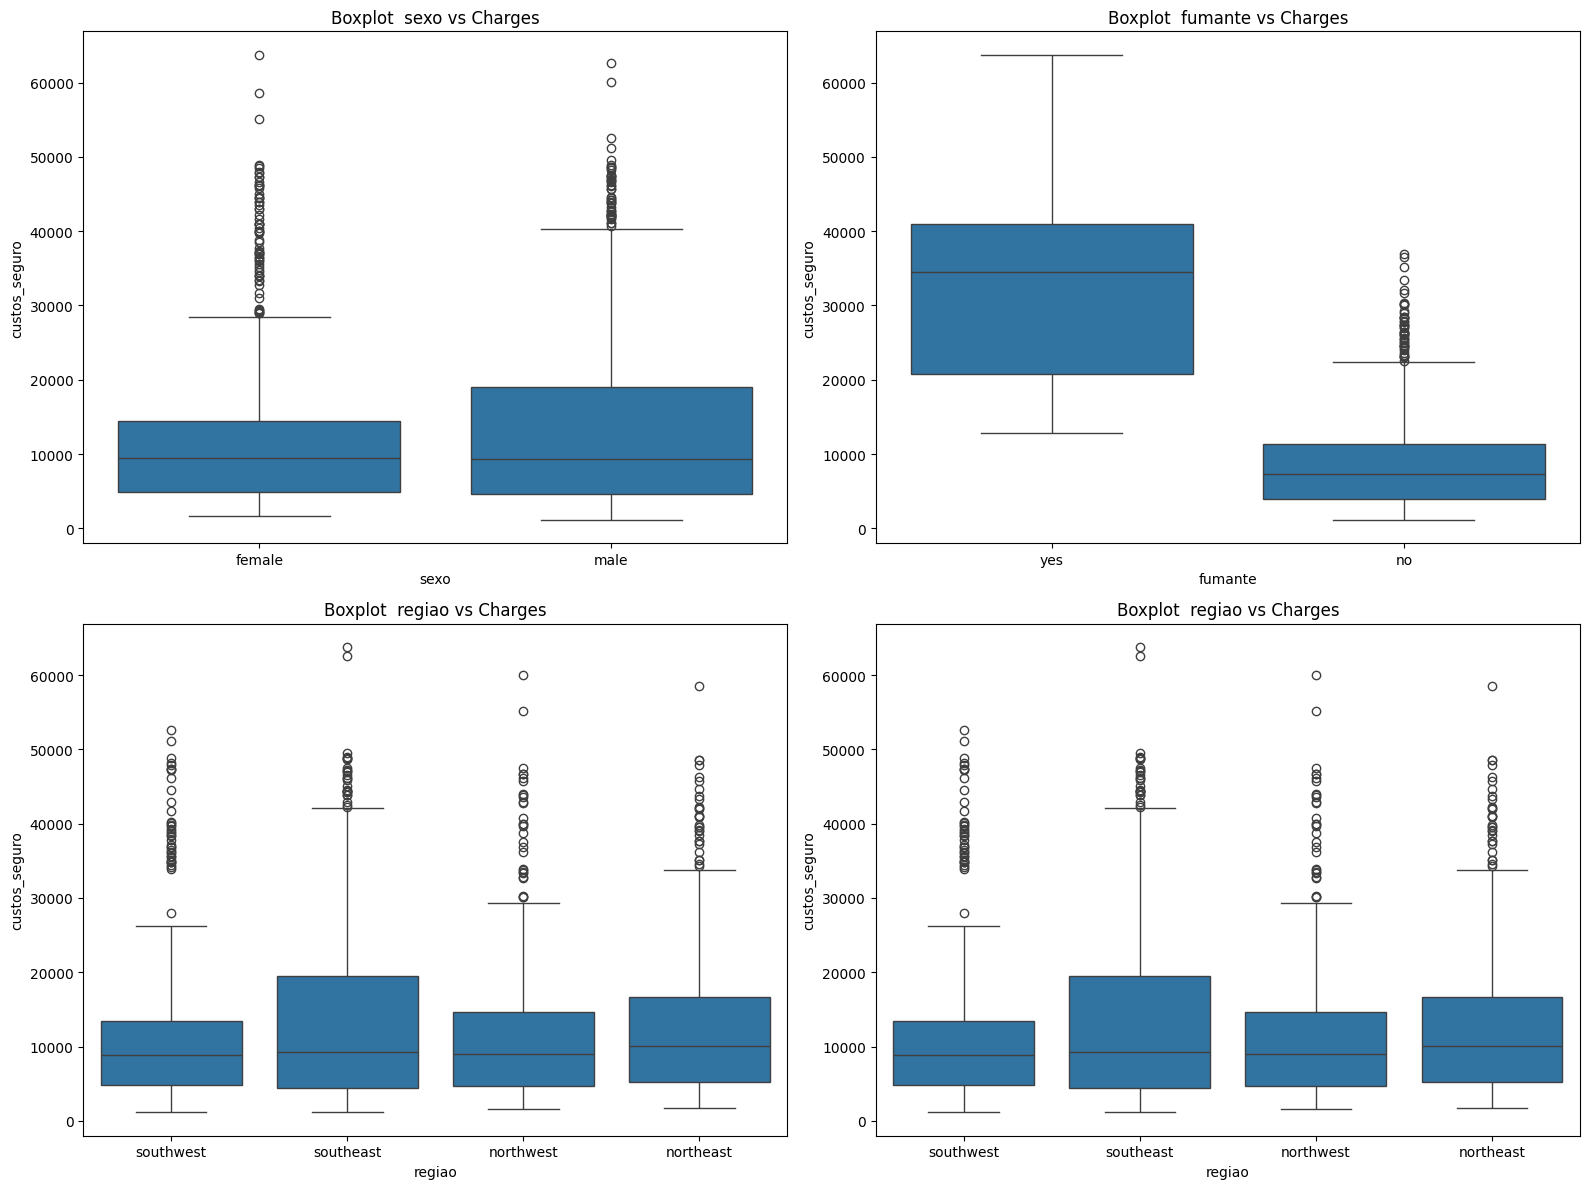

In [154]:
#observando custo_seguro por boxplot  por colunas

cat_plot_cols = ['sexo', 'fumante', 'regiao','regiao']

f,axes = plt.subplots(nrows= 2, ncols=2,figsize=(16,12))
for col,ax in zip(cat_plot_cols,axes.flatten()):
    sns.boxplot(x=col,y='custos_seguro',data=df,ax=ax)
    ax.set_title(f'Boxplot  {col} vs Charges')
# Ajustando layout
plt.tight_layout()
plt.show()

In [134]:
df.head()

,idade,sexo,imc,quantidade_filhos,fumante,regiao,custos_seguro
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.560,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [156]:
#observado pela OLS regressor que retirando a coluna de região temos um r2 de 75%

function = "custos_seguro ~ imc + quantidade_filhos + idade  + fumante -1 "
model = smf.ols(formula = function,data = df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          custos_seguro   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     998.1
Date:                Sun, 22 Dec 2024   Prob (F-statistic):               0.00
Time:                        02:17:21   Log-Likelihood:                -13551.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1333   BIC:                         2.714e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
fumante[no]        -1.21e+04    941.99

In [136]:
#definindo funções de metricas para analisar os modelos mais a frente
def get_metrics(y_true,y_pred):
    dict_metrics = {
        'R2': metrics.r2_score(y_true,y_pred),
        'MAE': metrics.mean_absolute_error(y_true,y_pred),
        'RMSE':np.sqrt(metrics.mean_squared_error(y_true,y_pred)),
    }
    return dict_metrics

In [157]:
#separando X e y para treina-los nos modelos
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=2023)

In [138]:
# Transformadores para variáveis numéricas e categóricas
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())
])

categorical_transformer = OneHotEncoder(
    drop='if_binary', handle_unknown='ignore', sparse_output=False
)

# Definir o ColumnTransformer com nomes
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, colunas_numericas),  # Nome: 'num'
    ('cat', categorical_transformer, Colunas_categoricas)  # Nome: 'cat'
])

preprocessor.fit_transform(X_train)


array([[0.23913043, 0.        , 0.52649987, ..., 0.        , 1.        ,
        0.        ],
       [0.93478261, 0.        , 0.75437181, ..., 0.        , 0.        ,
        1.        ],
       [0.43478261, 0.4       , 0.35781544, ..., 1.        , 0.        ,
        0.        ],
       ...,
       [0.17391304, 0.        , 0.65173527, ..., 1.        , 0.        ,
        0.        ],
       [0.30434783, 0.4       , 0.82243745, ..., 0.        , 1.        ,
        0.        ],
       [0.04347826, 0.        , 0.3669626 , ..., 0.        , 0.        ,
        1.        ]])

In [158]:
#um modelo separado com o linear regressor
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['idade', 'quantidade_filhos',
                                                   'imc']),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sexo', 'fumante',
                                                   'regiao'])])),
                ('model', LinearRegression())])

In [160]:
#valores da coluna de predicao
predicao = model_pipeline.predict(X_test)

print(predicao[:5])



[11616.42314521 11501.51286747 26816.71854388  7058.72024837
  7781.91483808]


In [162]:
#metricas de predicao
from sklearn import metrics as metrics
metrics = get_metrics(y_test, predicao)
print(metrics)

print("Métricas de desempenho do modelo:")
for metric, value in metrics.items():
    print(f"{metric}: {value}")

{'R2': 0.758476346371583, 'MAE': 4215.903658771695, 'RMSE': 6033.567215175}
Métricas de desempenho do modelo:
R2: 0.758476346371583
MAE: 4215.903658771695
RMSE: 6033.567215175


In [164]:
# anexando em paramentros novos modelos para teste de melhor modelo do grid search

params={
    'model': [LinearRegression(),
              DecisionTreeRegressor(),
              RandomForestRegressor(),
              AdaBoostRegressor(),
              GradientBoostingRegressor()]
}


grid_model = GridSearchCV(model_pipeline,params,cv=5,scoring='r2',verbose=1)
grid_model.fit(X_train,y_train)


Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          MinMaxScaler())]),
                                                                         ['idade',
                                                                          'quantidade_filhos',
                                                                          'imc']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='if_binary',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['sexo',
                                                                          'fumante',
                                                                          'regiao'])])),
                                       ('model', LinearRegression())]),
             param_grid={'model': [LinearRegression(), DecisionTreeRegressor(),
                                   RandomForestRegressor(), AdaBoostRegressor(),
                                   GradientBoostingRegressor()]},
             scoring='r2', verbose=1)

In [165]:
#melhor modelo
grid_model.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['idade', 'quantidade_filhos',
                                                   'imc']),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sexo', 'fumante',
                                                   'regiao'])])),
                ('model', GradientBoostingRegressor())])

In [147]:
#tabela para verificar diferença entre modelos
df_cv_results = pd.DataFrame(grid_model.cv_results_).sort_values('rank_test_score')

# Selecionando colunas que não contêm 'split' ou 'time'
filtered_columns = ~df_cv_results.columns.str.contains('split|time')
df_cv_results_filtered = df_cv_results.loc[:, filtered_columns]

# Exibindo o resultado
df_cv_results_filtered

,param_model,params,mean_test_score,std_test_score,rank_test_score
4,GradientBoostingRegressor(),{'model': GradientBoostingRegressor()},0.845406,0.024942,1
2,RandomForestRegressor(),{'model': RandomForestRegressor()},0.831008,0.031978,2
3,AdaBoostRegressor(),{'model': AdaBoostRegressor()},0.808605,0.017603,3
0,LinearRegression(),{'model': LinearRegression()},0.740824,0.015356,4
1,DecisionTreeRegressor(),{'model': DecisionTreeRegressor()},0.729265,0.057244,5


In [148]:
#TUNAGEM
model_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model'
     ,GradientBoostingRegressor(random_state=2023))
    ])

params={
    'model__learning_rate':[0.1,0.01],
    'model__max_depth':[3,4,5],
    'model__n_estimators':[300,400,500],
    'model__subsample':[1.,.8],
}

grid_model = GridSearchCV(model_pipeline,params,cv=5,scoring='r2',n_jobs=1, verbose=1)
grid_model.fit(X_train,y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          MinMaxScaler())]),
                                                                         ['idade',
                                                                          'quantidade_filhos',
                                                                          'imc']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='if_binary',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['sexo',
                                                                          'fumante',
                                                                          'regiao'])])),
                                       ('model',
                                        GradientBoostingRegressor(random_state=2023))]),
             n_jobs=1,
             param_grid={'model__learning_rate': [0.1, 0.01],
                         'model__max_depth': [3, 4, 5],
                         'model__n_estimators': [300, 400, 500],
                         'model__subsample': [1.0, 0.8]},
             scoring='r2', verbose=1)

In [149]:
#tabela para verificar diferença entre modelos
df_cv_results = pd.DataFrame(grid_model.cv_results_).sort_values('rank_test_score')

# Selecionando colunas que não contêm 'split' ou 'time'
filtered_columns = ~df_cv_results.columns.str.contains('split|time')
df_cv_results_filtered = df_cv_results.loc[:, filtered_columns]

# Exibindo o resultado
df_cv_results_filtered


,param_model__learning_rate,param_model__max_depth,param_model__n_estimators,param_model__subsample,params,mean_test_score,std_test_score,rank_test_score
20,0.01,3,400,1.0,"{'model__learning_rate': 0.01, 'model__max_dep...",0.855682,0.020749,1
22,0.01,3,500,1.0,"{'model__learning_rate': 0.01, 'model__max_dep...",0.855448,0.021801,2
21,0.01,3,400,0.8,"{'model__learning_rate': 0.01, 'model__max_dep...",0.855228,0.020424,3
23,0.01,3,500,0.8,"{'model__learning_rate': 0.01, 'model__max_dep...",0.854808,0.021113,4
19,0.01,3,300,0.8,"{'model__learning_rate': 0.01, 'model__max_dep...",0.853662,0.019229,5
18,0.01,3,300,1.0,"{'model__learning_rate': 0.01, 'model__max_dep...",0.853422,0.019256,6
26,0.01,4,400,1.0,"{'model__learning_rate': 0.01, 'model__max_dep...",0.850919,0.024194,7
27,0.01,4,400,0.8,"{'model__learning_rate': 0.01, 'model__max_dep...",0.850875,0.023393,8
25,0.01,4,300,0.8,"{'model__learning_rate': 0.01, 'model__max_dep...",0.850472,0.022345,9
24,0.01,4,300,1.0,"{'model__learning_rate': 0.01, 'model__max_dep...",0.849649,0.022147,10


In [167]:
#aqui escolhi que modelo para o pipeline seja o melhor do grid search que no caso foi gradient_boosting regressor
model_pipeline = grid_model.best_estimator_

In [169]:
#metricas do melhor modelo de predicao do grid search
from sklearn import metrics as metrics
y_pred = model_pipeline.predict(X_test)
get_metrics( y_test,y_pred)

{'R2': 0.8622505529544433,
 'MAE': 2557.6017408365938,
 'RMSE': 4556.582652465461}

In [171]:
import pickle
from google.colab import files

# Defina o caminho no Colab
file_path = '/content/model_pipeline.pkl'

# Abrindo o arquivo no modo de escrita binária
with open(file_path, 'wb') as file_model:
    # Serializando o modelo
    pickle.dump(model_pipeline, file_model)

# Baixando o arquivo para o computador
files.download(file_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [172]:
!python --version


Python 3.10.12


In [173]:
!pip list


Package                            Version
---------------------------------- --------------------
absl-py                            1.4.0
accelerate                         1.2.1
aiohappyeyeballs                   2.4.4
aiohttp                            3.11.10
aiosignal                          1.3.2
alabaster                          1.0.0
albucore                           0.0.19
albumentations                     1.4.20
altair                             5.5.0
annotated-types                    0.7.0
anyio                              3.7.1
argon2-cffi                        23.1.0
argon2-cffi-bindings               21.2.0
array_record                       0.5.1
arviz                              0.20.0
astropy                            6.1.7
astropy-iers-data                  0.2024.12.16.0.35.48
astunparse                         1.6.3
async-timeout                      4.0.3
atpublic                           4.1.0
attrs                              24.3.0
audioread        

In [174]:
!pip freeze > requirements.txt
